In [ ]:
import torch
import torchaudio

print(torch.__version__)
print(torchaudio.__version__)

torch.random.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

2.8.0+cu126
2.8.0+cu126
cuda


In [ ]:
import IPython
import matplotlib.pyplot as plt
from torchaudio.utils import download_asset

SPEECH_FILE = download_asset("tutorial-assets/Lab41-SRI-VOiCES-src-sp0307-ch127535-sg0042.wav")

/tmp/ipython-input-499805210.py:5: UserWarning: torchaudio.utils.download.download_asset has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  SPEECH_FILE = download_asset("tutorial-assets/Lab41-SRI-VOiCES-src-sp0307-ch127535-sg0042.wav")
100%|██████████| 106k/106k [00:00<00:00, 20.7MB/s]


In [ ]:
bundle = torchaudio.pipelines.WAV2VEC2_ASR_BASE_960H

print("Sample Rate:", bundle.sample_rate)

print("Labels:", bundle.get_labels())

Sample Rate: 16000
Labels: ('-', '|', 'E', 'T', 'A', 'O', 'N', 'I', 'H', 'S', 'R', 'D', 'L', 'U', 'M', 'W', 'C', 'F', 'G', 'Y', 'P', 'B', 'V', 'K', "'", 'X', 'J', 'Q', 'Z')


In [ ]:
model = bundle.get_model().to(device)

print(model.__class__)

<class 'torchaudio.models.wav2vec2.model.Wav2Vec2Model'>


In [ ]:
waveform, sample_rate = torchaudio.load(SPEECH_FILE)
waveform = waveform.to(device)

if sample_rate != bundle.sample_rate:
    waveform = torchaudio.functional.resample(waveform, sample_rate, bundle.sample_rate)

In [ ]:
with torch.inference_mode():
    features, _ = model.extract_features(waveform)

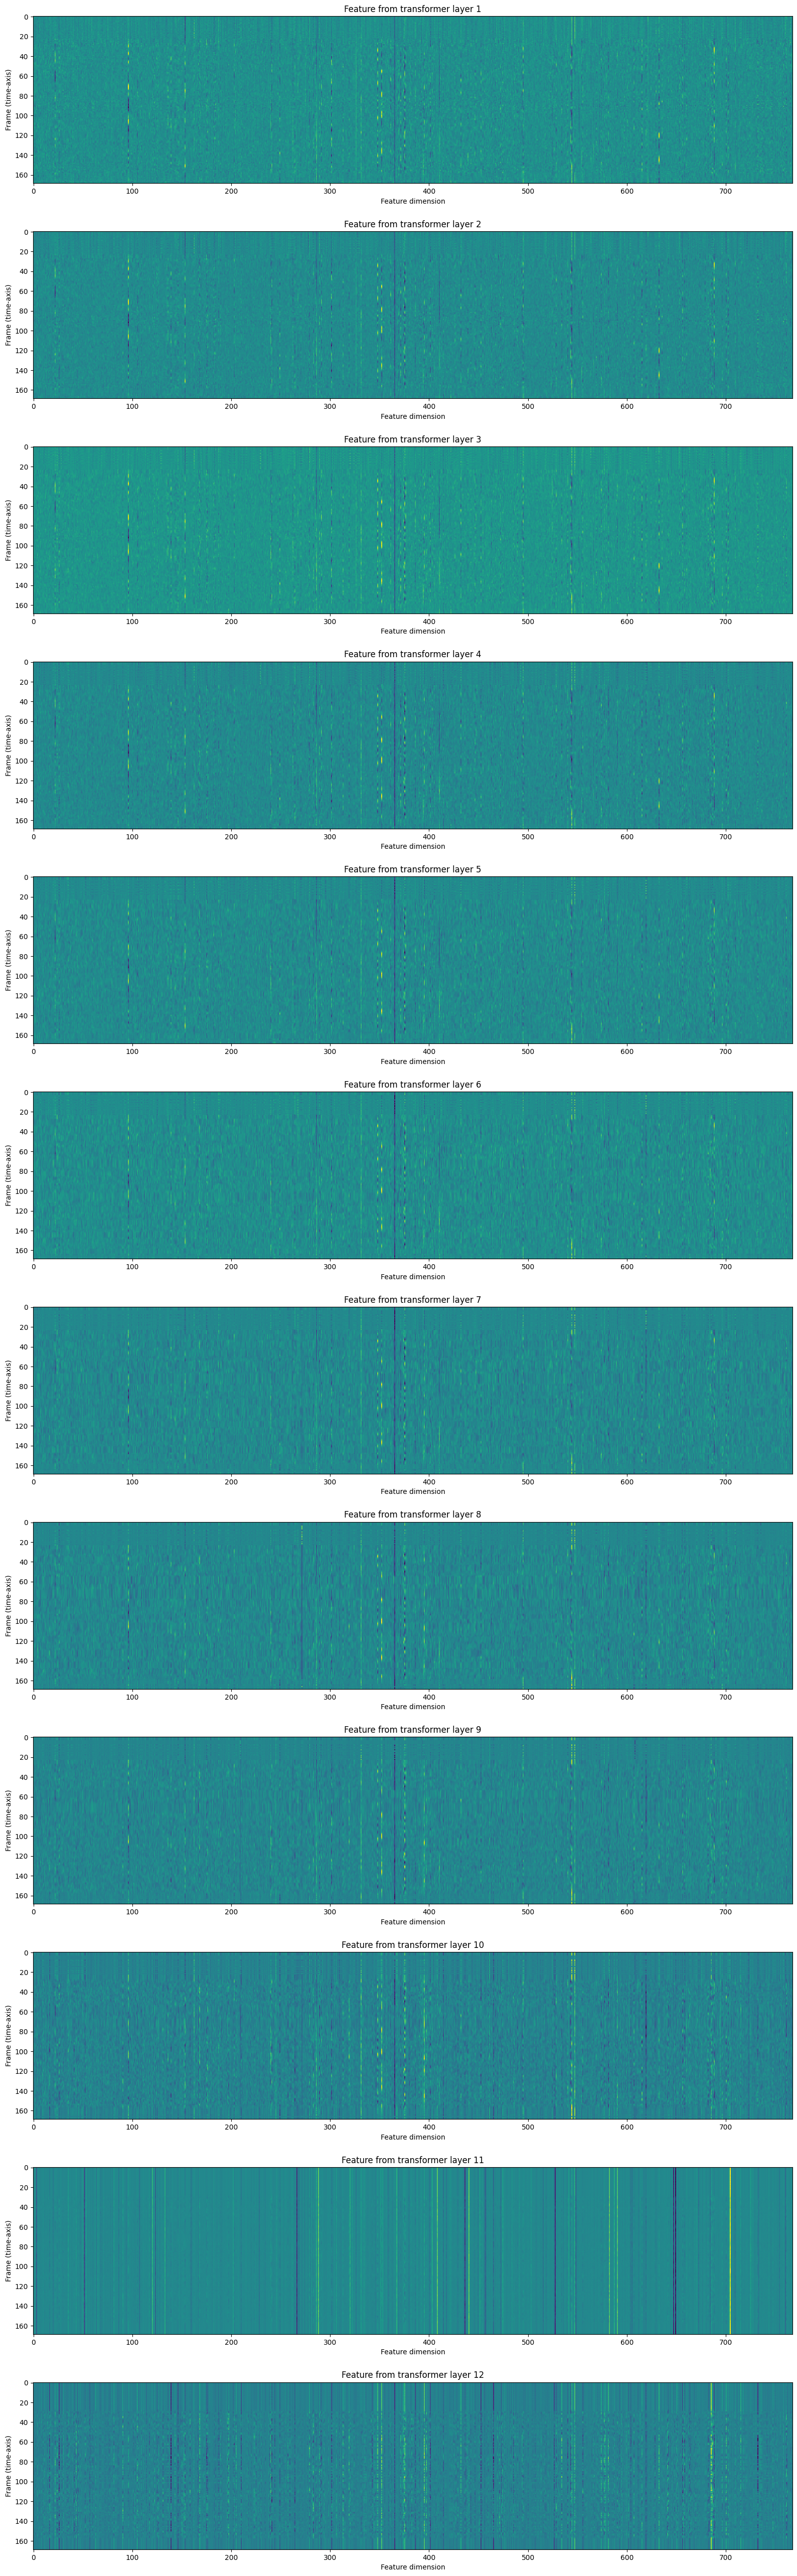

In [ ]:
fig, ax = plt.subplots(len(features), 1, figsize=(16, 4.3 * len(features)))
for i, feats in enumerate(features):
    ax[i].imshow(feats[0].cpu(), interpolation="nearest")
    ax[i].set_title(f"Feature from transformer layer {i+1}")
    ax[i].set_xlabel("Feature dimension")
    ax[i].set_ylabel("Frame (time-axis)")
fig.tight_layout()

In [ ]:
with torch.inference_mode():
    emission, _ = model(waveform)

Class labels: ('-', '|', 'E', 'T', 'A', 'O', 'N', 'I', 'H', 'S', 'R', 'D', 'L', 'U', 'M', 'W', 'C', 'F', 'G', 'Y', 'P', 'B', 'V', 'K', "'", 'X', 'J', 'Q', 'Z')


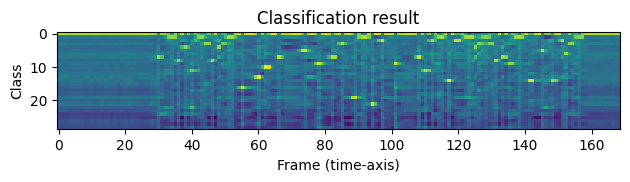

In [ ]:
plt.imshow(emission[0].cpu().T, interpolation="nearest")
plt.title("Classification result")
plt.xlabel("Frame (time-axis)")
plt.ylabel("Class")
plt.tight_layout()
print("Class labels:", bundle.get_labels())


In [ ]:
class GreedyCTCDecoder(torch.nn.Module):
    def __init__(self, labels, blank=0):
        super().__init__()
        self.labels = labels
        self.blank = blank

    def forward(self, emission: torch.Tensor) -> str:
        """Given a sequence emission over labels, get the best path string
        Args:
          emission (Tensor): Logit tensors. Shape `[num_seq, num_label]`.

        Returns:
          str: The resulting transcript
        """
        indices = torch.argmax(emission, dim=-1)  # [num_seq,]
        indices = torch.unique_consecutive(indices, dim=-1)
        indices = [i for i in indices if i != self.blank]
        return "".join([self.labels[i] for i in indices])

In [ ]:
decoder = GreedyCTCDecoder(labels=bundle.get_labels())
transcript = decoder(emission[0])

In [ ]:
print(transcript)
IPython.display.Audio(SPEECH_FILE)

I|HAD|THAT|CURIOSITY|BESIDE|ME|AT|THIS|MOMENT|


In [41]:
#m4a ver
from google.colab import files
uploaded = files.upload()

Saving AI_assignment-1.m4a to AI_assignment-1 (1).m4a


In [42]:
import torchaudio, torch

waveform, sr = torchaudio.load("AI_assignment-1.m4a")  # upload the recording file

if sr != 16000:
    waveform = torchaudio.functional.resample(waveform, sr, 16000)

with torch.inference_mode():
    emission, _ = model(waveform)

decoder = GreedyCTCDecoder(labels=bundle.get_labels())
transcript = decoder(emission[0])

print("recognized sentence :", transcript)

/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be r

recognized sentence : HULLO|BESIS|MY|FITZO|LACONISHANPE|FOR|THE|CLUFF|OF|FENMANT|TO|DAY|IS|OCTUBER|AS|W


In [44]:
#wav ver
from google.colab import files
uploaded = files.upload()

Saving AI_assignment-1.wav to AI_assignment-1 (3).wav


In [45]:
import torchaudio, torch

waveform, sr = torchaudio.load("AI_assignment-1.wav")

if sr != 16000:
    waveform = torchaudio.functional.resample(waveform, sr, 16000)

with torch.inference_mode():
    emission, _ = model(waveform)

decoder = GreedyCTCDecoder(labels=bundle.get_labels())
transcript = decoder(emission[0])

print("recognized sentence :", transcript)


recognized sentence : HULLO|BESIS|MY|FITZO|LACONISHANPE|FOR|THE|CLUFF|OF|FENMANT|TO|DAY|IS|OCTUBER|AS|W


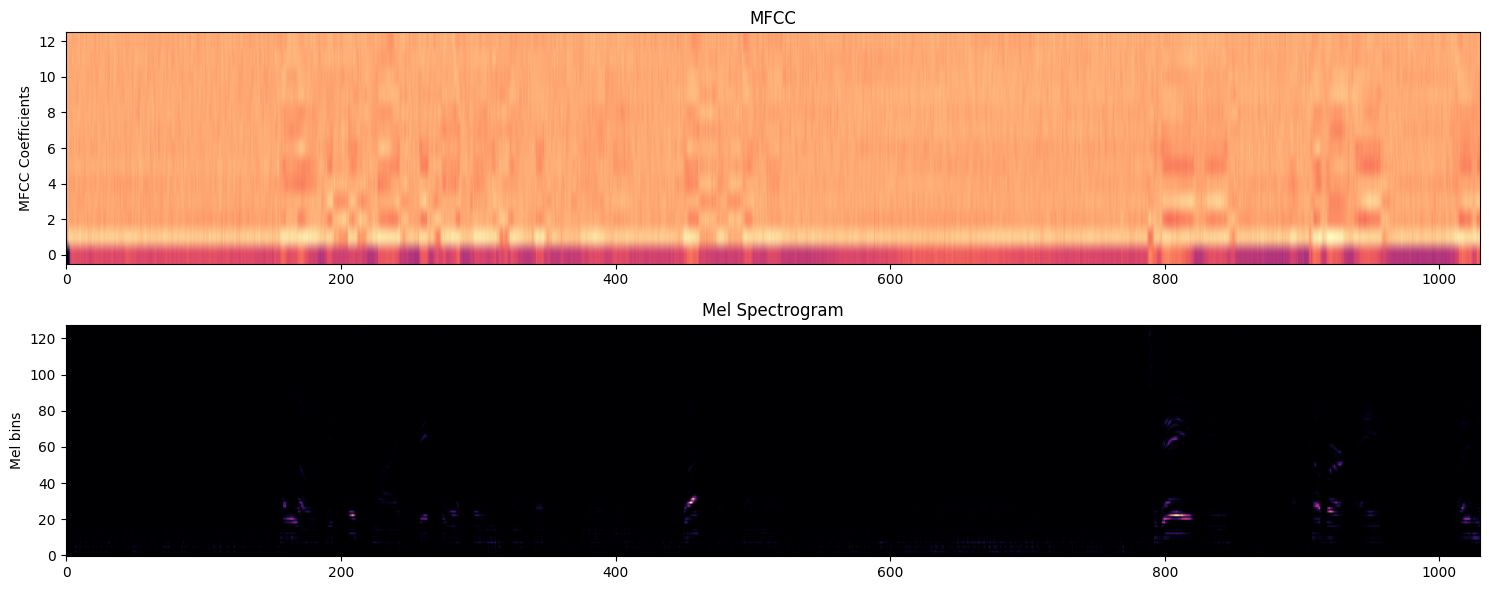

In [48]:
import torch
import torchaudio
import matplotlib.pyplot as plt

# -----------------------------------
# Feature Extraction
# -----------------------------------

# MFCC (Mel-frequency cepstral coefficients)
mfcc = torchaudio.transforms.MFCC(sample_rate=16000, n_mfcc=13)(waveform)

# Mel Spectrogram
mel = torchaudio.transforms.MelSpectrogram(sample_rate=16000)(waveform)

# -----------------------------------
# Visualization
# -----------------------------------

plt.figure(figsize=(15, 6))

# MFCC 시각화
plt.subplot(2, 1, 1)
plt.imshow(mfcc[0].numpy(), origin="lower", aspect="auto", cmap="magma")
plt.title("MFCC")
plt.ylabel("MFCC Coefficients")

# Mel Spectrogram 시각화
plt.subplot(2, 1, 2)
plt.imshow(mel[0].numpy(), origin="lower", aspect="auto", cmap="magma")
plt.title("Mel Spectrogram")
plt.ylabel("Mel bins")

plt.tight_layout()
plt.show()


Original Sample Rate: 48000, Shape: torch.Size([2, 617472])
✅ Audio preprocessing completed.



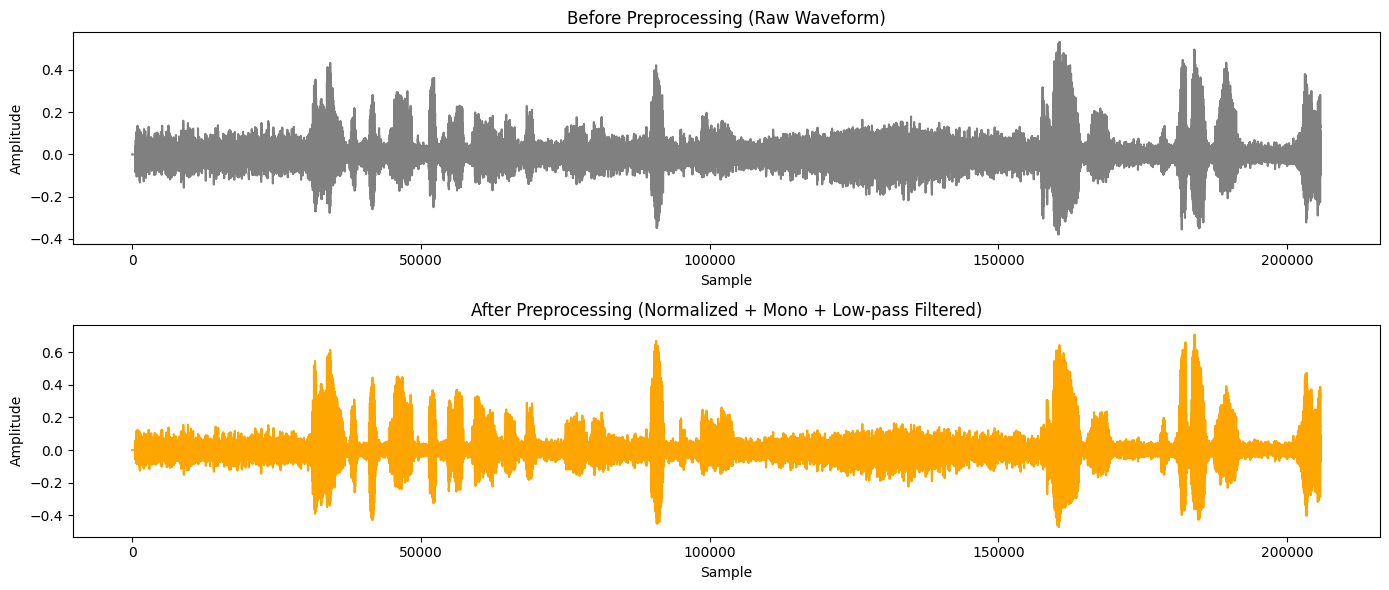

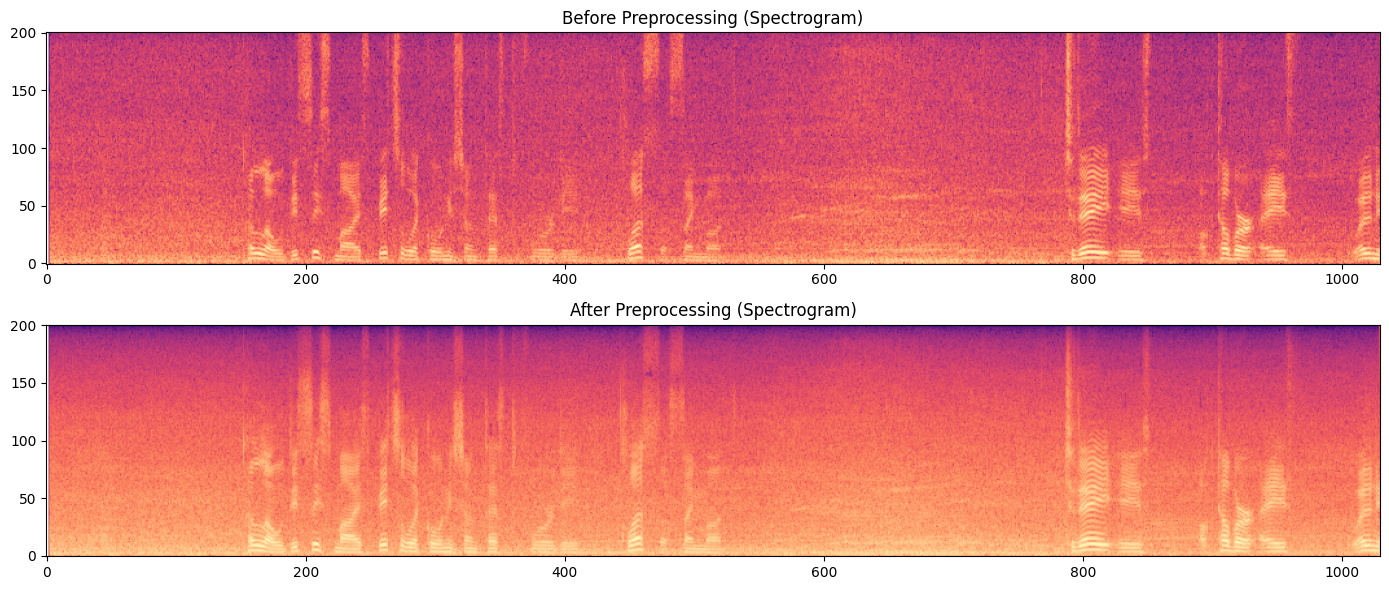

🗣️  Recognized Sentence (After Preprocessing):

HELLO DISIS MY SPITALACONICIANTESTE FOR THE CLASSA SAM MONT TO DAY IS OCTOBER A WE


In [51]:
# =====================================================
# Speech Recognition with Audio Preprocessing
# =====================================================

import torch
import torchaudio
import matplotlib.pyplot as plt

# --------------------------------------------
# Load Audio File
# --------------------------------------------
waveform_raw, sr = torchaudio.load("AI_assignment-1.wav")
print(f"Original Sample Rate: {sr}, Shape: {waveform_raw.shape}")

# Resample to 16kHz (model input requirement)
if sr != 16000:
    waveform_raw = torchaudio.functional.resample(waveform_raw, sr, 16000)
    sr = 16000

# --------------------------------------------
# Audio Preprocessing for Accuracy Improvement
# --------------------------------------------
# (1) Normalize the volume
waveform_clean = waveform_raw / waveform_raw.abs().max()

# (2) Convert stereo to mono
if waveform_clean.shape[0] > 1:
    waveform_clean = waveform_clean.mean(dim=0, keepdim=True)

# (3) Apply low-pass filter to remove high-frequency noise
waveform_clean = torchaudio.functional.lowpass_biquad(
    waveform_clean,
    sample_rate=16000,
    cutoff_freq=3000
)

print("✅ Audio preprocessing completed.\n")

# --------------------------------------------
# Visualization: Before vs After Preprocessing
# --------------------------------------------
plt.figure(figsize=(14, 6))

# Before Preprocessing
plt.subplot(2, 1, 1)
plt.plot(waveform_raw[0].numpy(), color='gray')
plt.title("Before Preprocessing (Raw Waveform)")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

# After Preprocessing
plt.subplot(2, 1, 2)
plt.plot(waveform_clean[0].numpy(), color='orange')
plt.title("After Preprocessing (Normalized + Mono + Low-pass Filtered)")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

# --------------------------------------------
# Spectrogram Comparison (Frequency Visualization)
# --------------------------------------------
spec = torchaudio.transforms.Spectrogram()(waveform_raw)
spec_clean = torchaudio.transforms.Spectrogram()(waveform_clean)

plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1)
plt.imshow(spec.log2()[0, :, :].numpy(), origin='lower', aspect='auto', cmap='magma')
plt.title("Before Preprocessing (Spectrogram)")

plt.subplot(2, 1, 2)
plt.imshow(spec_clean.log2()[0, :, :].numpy(), origin='lower', aspect='auto', cmap='magma')
plt.title("After Preprocessing (Spectrogram)")

plt.tight_layout()
plt.show()

# --------------------------------------------
# Speech Recognition (Wav2Vec2)
# --------------------------------------------
from torchaudio.pipelines import WAV2VEC2_ASR_BASE_960H

bundle = WAV2VEC2_ASR_BASE_960H
model = bundle.get_model()

with torch.inference_mode():
    emission, _ = model(waveform_clean)

# Greedy Decoder
class GreedyCTCDecoder(torch.nn.Module):
    def __init__(self, labels, blank=0):
        super().__init__()
        self.labels = labels
        self.blank = blank
    def forward(self, emission: torch.Tensor) -> str:
        indices = torch.argmax(emission, dim=-1)
        indices = torch.unique_consecutive(indices)
        indices = [i for i in indices if i != self.blank]
        return "".join([self.labels[i] for i in indices])

decoder = GreedyCTCDecoder(labels=bundle.get_labels())
transcript = decoder(emission[0])

# --------------------------------------------
# Display Results
# --------------------------------------------
print("🗣️  Recognized Sentence (After Preprocessing):\n")
print(transcript.replace("|", " "))